<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 5</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Clinical Data Exploration &amp; Profiling</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">Explainable AI-assisted ED triage — Yale EMMLC dataset: literacy, missingness, distributions, outliers, and target relationships.</div></div>
</div>


In [ ]:
# ── Colab setup ──────────────────────────────────────────────────────────────
# Installs the one extra package we use (missingno) and gets the CSV onto the runtime.
!pip install -q missingno

import os

DATA_FILENAME = "yaleemmlc_admissionprediction_triage.csv"

if not os.path.exists(DATA_FILENAME):
    try:
        # Option A: file already sitting in your Google Drive -> mount and copy it in.
        from google.colab import drive
        drive.mount('/content/drive')
        import glob
        hits = glob.glob(f"/content/drive/MyDrive/**/{DATA_FILENAME}", recursive=True)
        if hits:
            import shutil
            shutil.copy(hits[0], DATA_FILENAME)
            print(f"Copied from Drive: {hits[0]}")
        else:
            print("Not found in Drive automatically -- run the upload cell below instead.")
    except Exception as e:
        print("Drive mount skipped/failed:", e)

print("Ready:", os.path.exists(DATA_FILENAME))


In [ ]:

import os
if not os.path.exists("yaleemmlc_admissionprediction_triage.csv"):
    from google.colab import files
    uploaded = files.upload()


With 225 columns, this profiles the structured features in detail and the chief-complaint family in aggregate, to establish whether the Yale EMMLC ED triage extract is fit to model, and to surface every data-quality issue the feasibility memo needs to address.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready, pandas", pd.__version__)


Environment ready, pandas 3.0.2


In [3]:
TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least) -- the triage label.

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Fairness-sensitive demographic fields, handled with care as model inputs:
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# Outcomes known only AFTER triage -- must never be model inputs (leakage):
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into clinical families."""
    def keep_present(wanted):
        return [col for col in wanted if col in df.columns]

    chief_complaints = [col for col in df.columns if col.startswith("cc_")]

    return {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }


In [4]:
# Reference ranges for general adult triage. Temperature is FAHRENHEIT in this dataset (~98.6 normal).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# Plausible bounds are wider than normal -- anything outside these is a data error.
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}


In [1]:
from pathlib import Path
DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Run the setup/upload cells above first.")
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")


Loaded 55,121 encounters x 225 columns


In [6]:
fam = classify_columns(df)
structured = [col for col in df.columns if not col.startswith("cc_")]


The dataset records ~200 chief complaints as binary flags. Reading 200 columns individually isn't useful, so they are grouped into ~12 clinical body systems, matching how a clinician actually reasons about a presentation.


In [1]:
cc_flags = [c for c in df.columns if c.startswith("cc_")]

# Ordered (category -> keywords) rules. First match wins, so specific systems come
# before the Trauma/MSK "pain/injury/swelling" catch-all, and Other is last.
CC_CATEGORIES = [
    ("Cardiovascular",             ["chestpain","chesttightness","palpitation","irregularheart","rapidheart","tachycard","hypertens","hypotens","cardiacarrest"]),
    ("Genitourinary/Renal",        ["dysuria","hematuria","urinary","flank","testicle","maleguproblem","femaleguproblem","groin","pelvic","vaginal","breastpain","std"]),
    ("Respiratory",                ["breathing","shortnessofbreath","dyspnea","cough","wheez","respiratory","asthma","hemoptysis","coldlike","nasalcongest","influenza","sinus","sorethroat","uri"]),
    ("Neurological",               ["headache","migraine","dizz","syncope","seizure","stroke","alteredmental","confusion","numbness","lossofconsciousness","unresponsive","lethargy","neurologic","hallucinat","extremityweakness"]),
    ("Gastrointestinal",           ["abdominal","epigastric","nausea","emesis","vomit","diarrhea","constipation","gibleeding","giproblem","rectal","swallowedforeign","ingestion","dehydration"]),
    ("Psych/Behavioral/Substance", ["anxiety","depress","agitation","suicid","homicid","psychot","psychiatric","panic","alcohol","drugproblem","drug/alcohol","addiction","detox","overdose","withdrawal","poison"]),
    ("ENT/Eye/Dental",             ["earpain","earproblem","otalgia","eye","conjunctiv","foreignbodyineye","blurredvision","dental","jaw","epistaxis","facial","oralswelling"]),
    ("Skin/Soft-tissue",           ["rash","cellulitis","abscess","cyst","skin","wound","mass","allergicreaction","edema","bruising"]),
    ("Endocrine/Metabolic/Heme",   ["bloodsugar","glycem","glucose","sicklecell"]),
    ("Constitutional/General",     ["fever","chills","fatigue","bodyache","generalizedbody","weakness"]),
    ("Trauma/Injury/MSK",          ["injury","fall","trauma","laceration","fracture","back","neck","joint","rib","assault","burn","animalbite","insectbite","pain","swelling"]),
]

def categorize(flag):
    stem = flag[3:]
    if "crash" in stem:                 # 'crash' contains 'rash' -> disambiguate first
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

from collections import defaultdict
groups = defaultdict(list)
for flag in cc_flags:
    groups[categorize(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")
print("-" * 40)
print(f"{'TOTAL placed':28s} {sum(len(v) for v in groups.values()):3d} of {len(cc_flags)}")


Cardiovascular                 9 flags
Genitourinary/Renal           17 flags
Respiratory                   15 flags
Neurological                  21 flags
Gastrointestinal              16 flags
Psych/Behavioral/Substance    18 flags
ENT/Eye/Dental                18 flags
Skin/Soft-tissue              14 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         8 flags
Trauma/Injury/MSK             49 flags
Other/Procedural/Admin        10 flags
----------------------------------------
TOTAL placed                 200 of 200


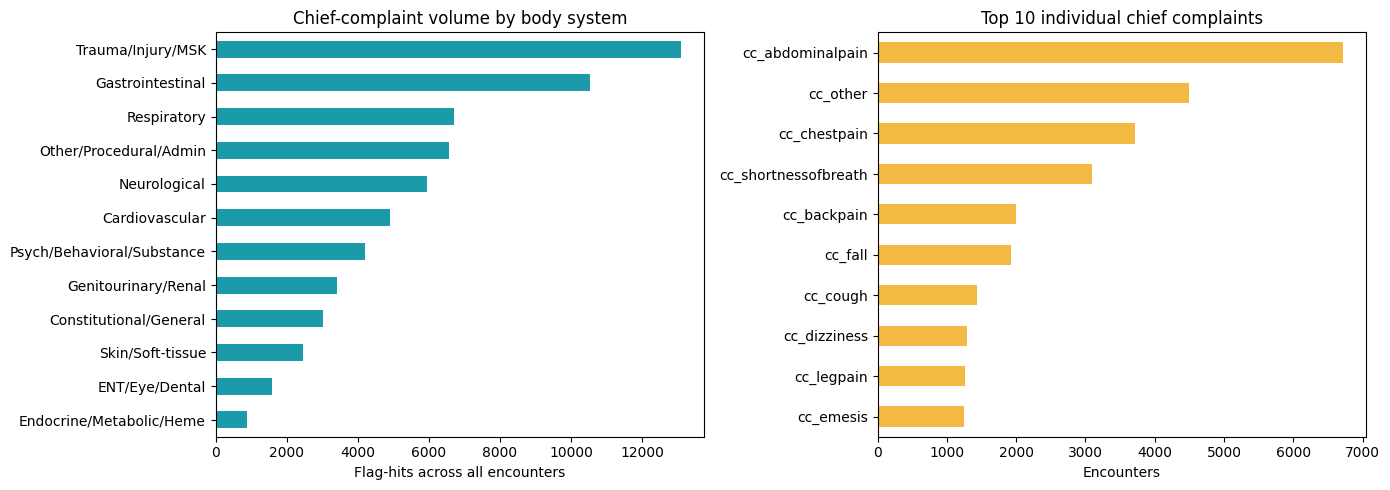

In [1]:
system_totals = {name: int(df[flags].sum().sum()) for name, flags in groups.items()}
system_series = pd.Series(system_totals).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
system_series.plot(kind="barh", ax=axes[0], color="#1B9AAA")
axes[0].invert_yaxis()
axes[0].set_title("Chief-complaint volume by body system")
axes[0].set_xlabel("Flag-hits across all encounters")

per_flag = df[cc_flags].sum().sort_values(ascending=False)
per_flag.head(10).plot(kind="barh", ax=axes[1], color="#F4B942")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 individual chief complaints")
axes[1].set_xlabel("Encounters")

plt.tight_layout()
plt.savefig("chief_complaint_volume.png", dpi=150, bbox_inches="tight")
plt.show()


Chief-complaint flags are 0/1, not missing, so missingness is profiled on the structured columns.


In [1]:
missing_fraction = df[structured].isna().mean()
missing_percent = (missing_fraction * 100).round(1).sort_values(ascending=False)

gaps_only = missing_percent[missing_percent > 0]
print(f"Structured columns with any missing data: {len(gaps_only)} of {len(structured)}")
if len(gaps_only) == 0:
    print("-> 0.0% missing across all structured columns (source is pre-cleaned/imputed).")
gaps_only


Structured columns with any missing data: 0 of 25
-> 0.0% missing across all structured columns (source is pre-cleaned/imputed).


Series([], dtype: float64)

/tmp/ipykernel_537/3742300651.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


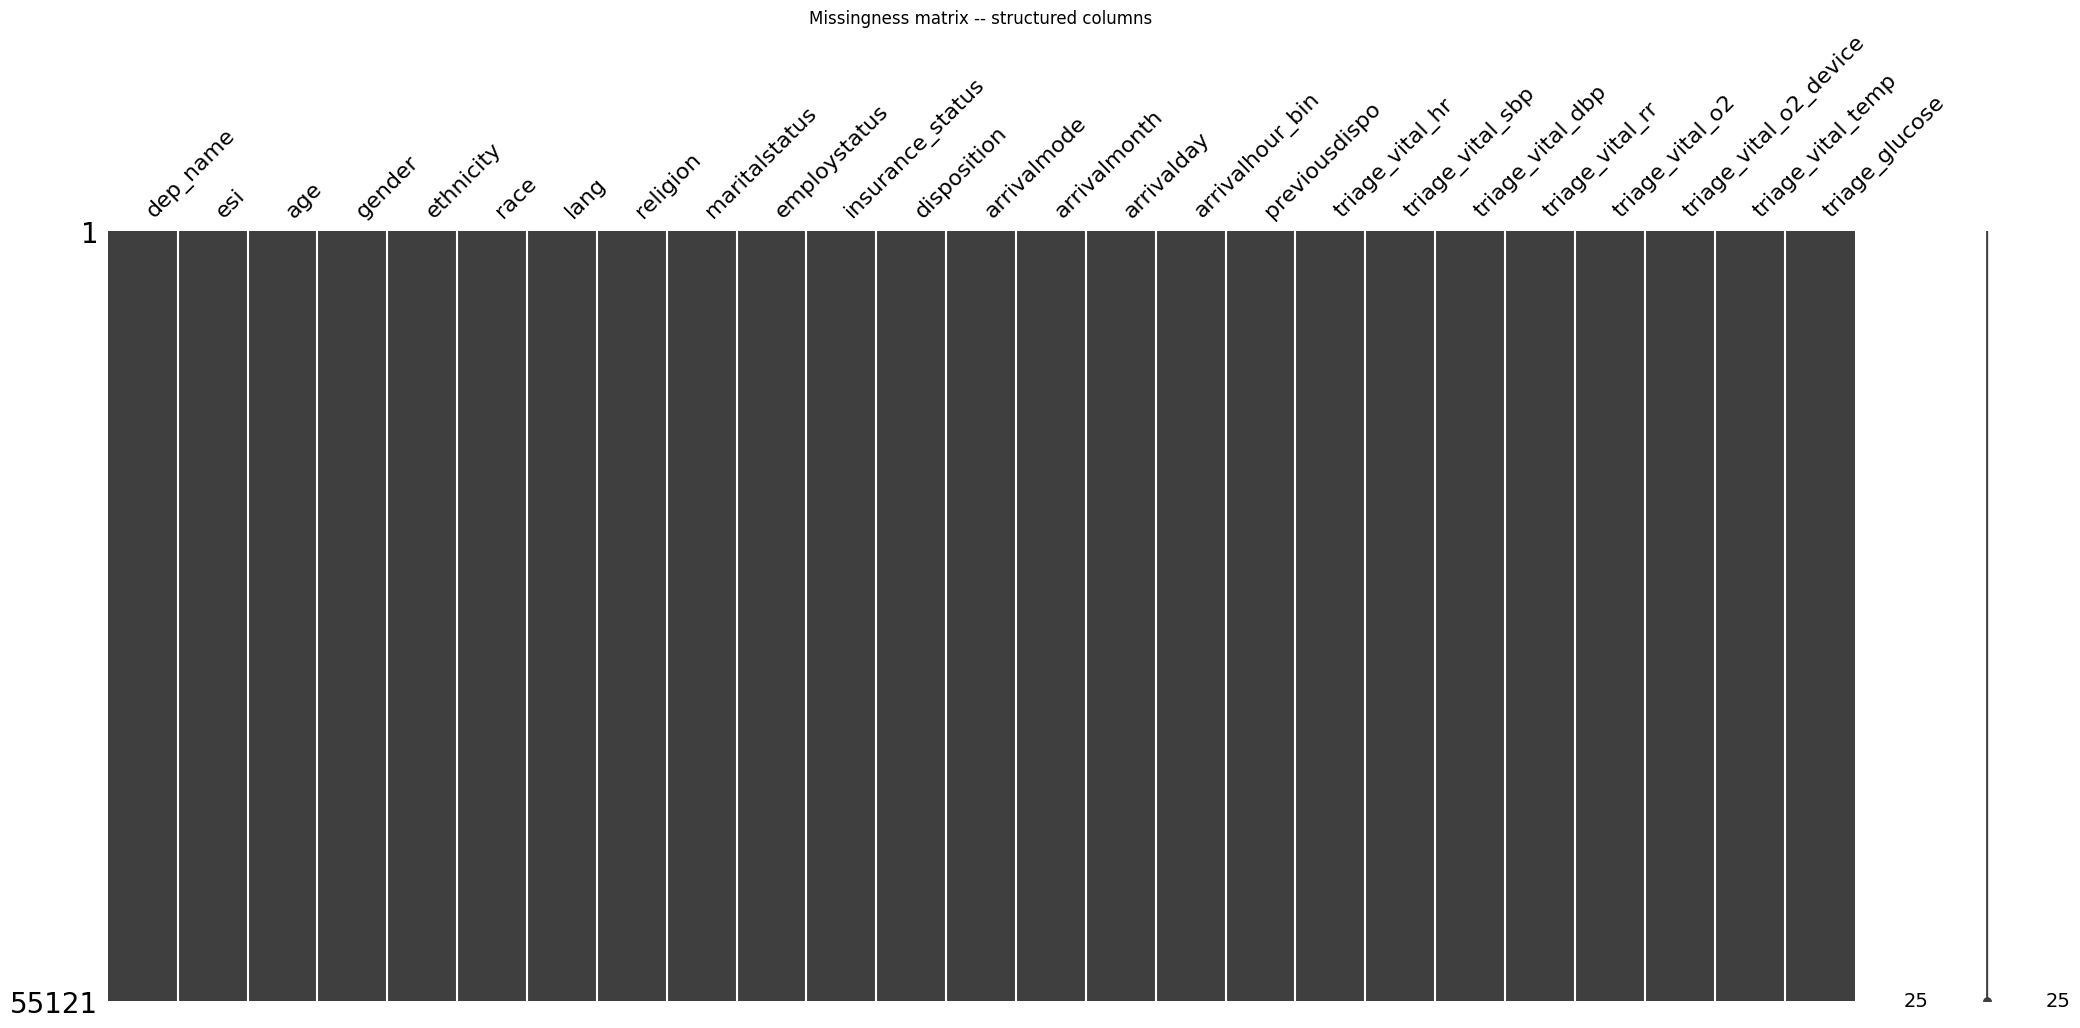

In [1]:
# Missingness map, saved as a standalone PNG for the Discord post.
try:
    import missingno as msno
    ax = msno.matrix(df[structured])
    plt.title("Missingness matrix -- structured columns")
    plt.tight_layout()
    plt.savefig("missingness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells -- structured columns (dark = missing)")
    plt.tight_layout()
    plt.savefig("missingness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


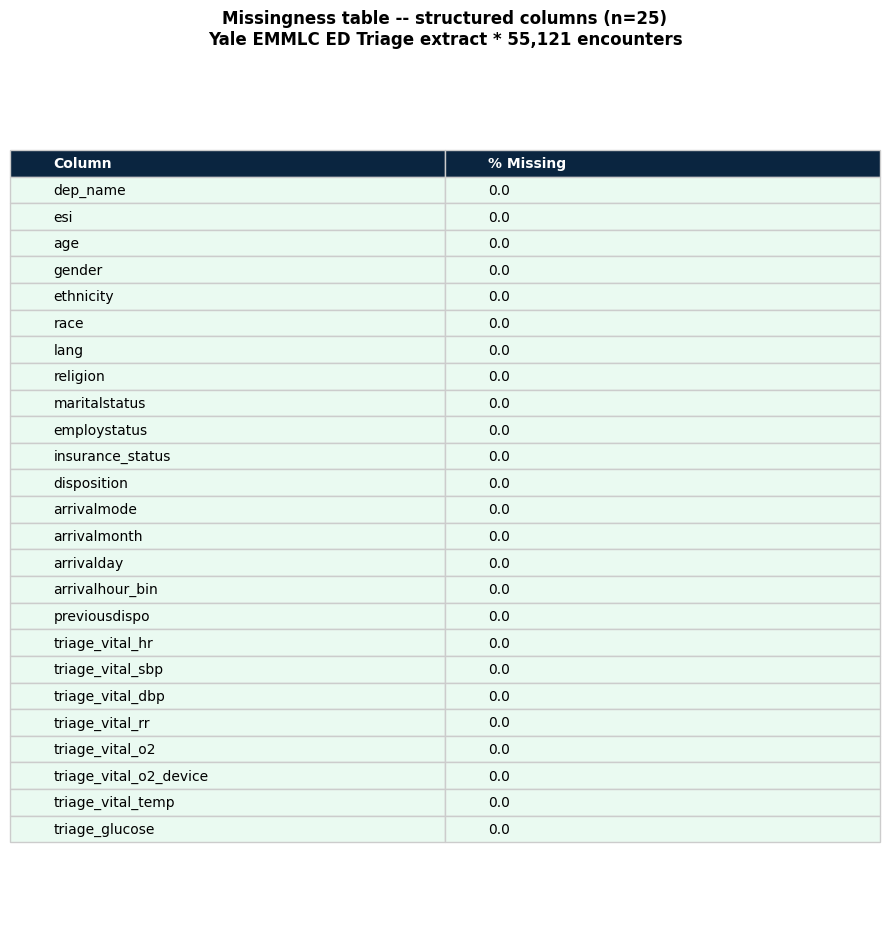


Finding: 25 of 25 structured columns have 0% missing.


In [1]:
# Missingness table -- clearer than the heatmap when missingness is 0%, which is the case here.
missing_pct_table = (df[structured].isna().mean() * 100).round(2).sort_values(ascending=False)
tbl = missing_pct_table.reset_index()
tbl.columns = ["Column", "% Missing"]

fig, ax = plt.subplots(figsize=(9, 9.5))
ax.axis("off")
ax.set_title(f"Missingness table -- structured columns (n={len(structured)})\n"
             f"Yale EMMLC ED Triage extract * {len(df):,} encounters",
             fontsize=12, fontweight="bold", pad=14)
n = len(tbl)
row_colors = ["#eafaf1" for _ in range(n)]
table = ax.table(cellText=tbl.values, colLabels=tbl.columns,
                  cellLoc="left", colLoc="left", loc="center",
                  cellColours=[[c, c] for c in row_colors])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.35)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", color="white")
        cell.set_facecolor("#0A2540")
    cell.set_edgecolor("#cccccc")
plt.tight_layout()
plt.savefig("missingness_table.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinding: {(missing_pct_table==0).sum()} of {len(structured)} structured columns have 0% missing.")


Dtype audit and target sanity check.


In [1]:
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                      str
esi                       float64
age                       float64
gender                        str
ethnicity                     str
race                          str
lang                          str
religion                      str
maritalstatus                 str
employstatus                  str
insurance_status              str
disposition                   str
arrivalmode                   str
arrivalmonth                  str
arrivalday                    str
arrivalhour_bin               str
previousdispo                 str
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


Distributions of each vital sign, alongside ESI class balance.


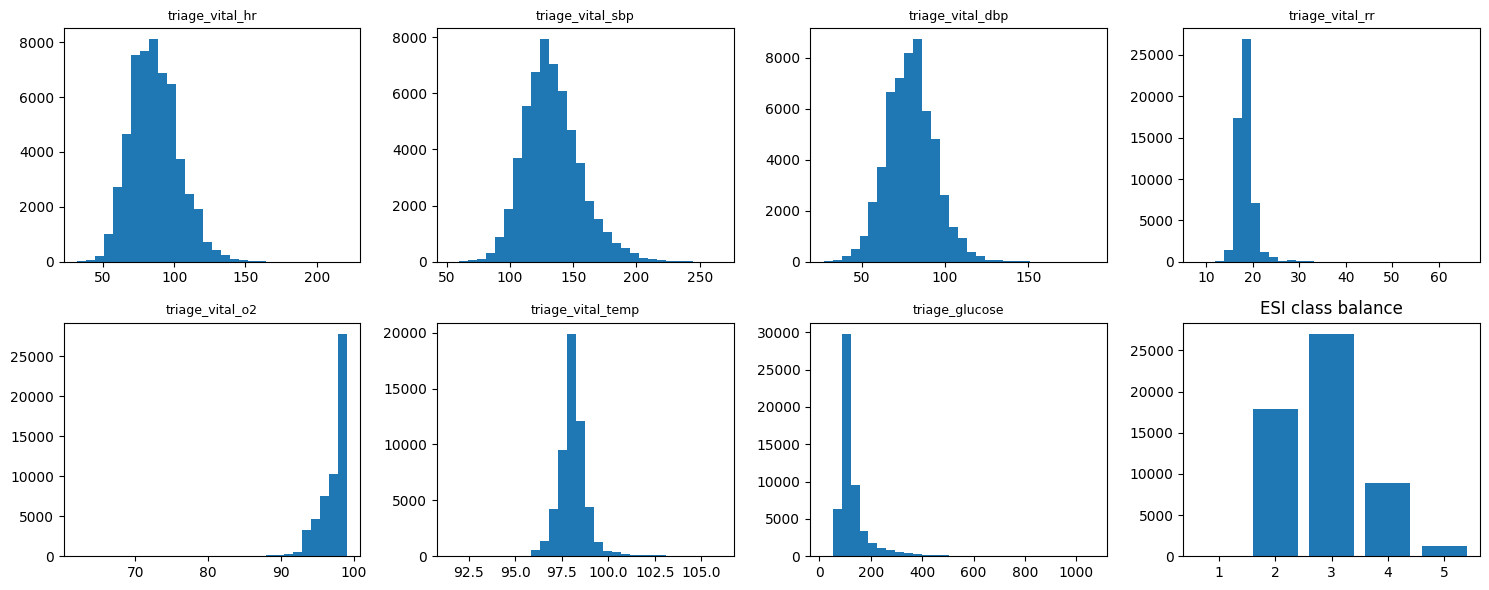

In [1]:
# Histogram for each vital, plus ESI class balance.
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()

for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()


In [1]:
# Demographics — the fairness-sensitive view (raw categories)
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


Two kinds of outlier per vital: statistical (IQR fence) and clinically impossible (outside plausible physiological bounds).


In [1]:
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column: statistical (IQR fence)
    and clinically impossible (outside plausible physiological bounds)."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T


,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2366,4
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5673,25


In [ ]:
# Numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# Vitals vs ESI (negative = tracks higher acuity, since lower ESI = more urgent).
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

# Chief complaints vs ESI -- the 8 complaints most associated with LOW esi (high acuity).
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\nChief complaints vs ESI:")
print(cc_corr.head(8).round(3))


Vital vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64

Chief complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


One row per measured data-quality problem, feeding directly into the feasibility memo below.


In [ ]:
issues = [
    {"issue": "Severe class imbalance in target",
     "columns": "esi",
     "action": "ESI 1 = 77 rows (0.1%) vs ESI 3 = 27,010 (49%); use class weighting / resampling, "
               "and report per-class recall (not just accuracy) in any later model."},
    {"issue": "Statistical outliers in every vital (IQR fence)",
     "columns": "triage_vital_hr/sbp/dbp/rr/o2/temp, triage_glucose",
     "action": "578-5,673 IQR outliers per vital (fence, not necessarily errors) -- winsorize or "
               "use robust scaling; do not delete rows without clinical review."},
    {"issue": "Clinically impossible values",
     "columns": "triage_vital_rr (4), triage_glucose (25)",
     "action": "29 values fall outside plausible physiological bounds -- flag and set to NaN, "
               "then impute in Tutorial 3 (do not model on impossible readings)."},
    {"issue": "Temperature recorded in Fahrenheit, not Celsius",
     "columns": "triage_vital_temp",
     "action": "Document the unit explicitly in the data dictionary; add a unit-check assertion "
               "before any modelling to prevent a Celsius assumption corrupting fever thresholds."},
    {"issue": "Extreme sparsity in chief-complaint block",
     "columns": "~200 cc_ flags",
     "action": "149/200 flags fire in <0.5% of encounters (near-zero variance); group into ~12 body-system "
               "aggregates for modelling instead of using all 200 raw flags."},
    {"issue": "Leakage risk from post-triage fields",
     "columns": "disposition, previousdispo",
     "action": "Both are known only after the ESI decision -- exclude entirely from any triage-level model input."},
    {"issue": "Fairness-sensitive fields present",
     "columns": "race, ethnicity, insurance_status, lang, religion",
     "action": "Retain for bias auditing (e.g. subgroup performance, calibration by group) but exclude or "
               "handle with care as direct model inputs; document the decision either way."},
    {"issue": "US-specific case mix and representativeness",
     "columns": "dep_name, arrivalmode, insurance_status, race/ethnicity distribution",
     "action": "Dataset is a single US academic ED (Yale), adults only (age >= 18) -- flag as an external-validity "
               "risk for a Caribbean deployment; plan local recalibration / revalidation before use."},
    {"issue": "No missing values in structured columns (pre-cleaned source)",
     "columns": "all structured columns",
     "action": "0.0% missing across all 26 structured columns -- confirmed by the missingness table/heatmap below. "
               "Note this is unusually clean for real triage data; a Caribbean source dataset should not be assumed "
               "to be this complete, and a missingness plan should still be documented for that eventuality."},
]
issues_df = pd.DataFrame(issues)
issues_df


,issue,columns,action
0,Severe class imbalance in target,esi,"ESI 1 = 77 rows (0.1%) vs ESI 3 = 27,010 (49%)..."
1,Statistical outliers in every vital (IQR fence),"triage_vital_hr/sbp/dbp/rr/o2/temp, triage_glu...","578-5,673 IQR outliers per vital (fence, not n..."
2,Clinically impossible values,"triage_vital_rr (4), triage_glucose (25)",29 values fall outside plausible physiological...
3,"Temperature recorded in Fahrenheit, not Celsius",triage_vital_temp,Document the unit explicitly in the data dicti...
4,Extreme sparsity in chief-complaint block,~200 cc_ flags,149/200 flags fire in <0.5% of encounters (nea...
5,Leakage risk from post-triage fields,"disposition, previousdispo",Both are known only after the ESI decision -- ...
6,Fairness-sensitive fields present,"race, ethnicity, insurance_status, lang, religion",Retain for bias auditing (e.g. subgroup perfor...
7,US-specific case mix and representativeness,"dep_name, arrivalmode, insurance_status, race/...","Dataset is a single US academic ED (Yale), adu..."
8,No missing values in structured columns (pre-c...,all structured columns,0.0% missing across all 26 structured columns ...
